In [ ]:
%pip install deepcell python-dotenv

In [19]:
import os
from pathlib import Path
from dotenv import load_dotenv

env_path = Path.cwd() / '.env'
if not env_path.exists():
    env_path = Path.cwd() / 'Cell_Segmentation' / '.env'
load_dotenv(env_path)

if not os.getenv('DEEPCELL_ACCESS_TOKEN'):
    raise RuntimeError('DEEPCELL_ACCESS_TOKEN was not found in .env')


In [4]:
from deepcell.datasets import TissueNet

tissuenet = TissueNet(version='1.1')

INFO:root:Checking for cached data
INFO:root:Making request to server
INFO:root:Downloading data/tissuenet/tissuenet_v1-1.zip with size 4.1 GB to C:\Users\asus\.deepcell\datasets
4.08GB [03:54, 18.7MB/s]                             
INFO:root:🎉 Successfully downloaded file to C:\Users\asus\.deepcell\datasets\tissuenet_v1-1.zip
INFO:root:Extracting C:\Users\asus\.deepcell\datasets\tissuenet_v1-1.zip
INFO:root:Successfully extracted C:\Users\asus\.deepcell\datasets\tissuenet_v1-1.zip into C:\Users\asus\.deepcell\datasets


## RQ 1: Can a simple U-Net provide a reasonable baseline for cell/nuclear segmentation on TissueNet?

In [1]:
import torch
from torch.utils.data import DataLoader, Subset

from unet import UNet
from tissuenet_data import TissueNetDataset, random_crop
from training_utils import dice_score, train_one_epoch,evaluate

In [2]:
import os

import numpy as np
import skimage.io as io

from deepcell.utils.plot_utils import create_rgb_image
from deepcell.utils.plot_utils import make_outline_overlay

npz_dir = r"C:\Users\asus\.deepcell\datasets\tissuenet_v1-1"
train_dict = np.load(os.path.join(npz_dir, 'train.npz'),allow_pickle=True)
val_dict = np.load(os.path.join(npz_dir, 'val.npz'),allow_pickle=True)
test_dict = np.load(os.path.join(npz_dir, 'test.npz'),allow_pickle=True)


In [2]:
print(val_dict.keys())

KeysView(NpzFile 'C:\\Users\\asus\\.deepcell\\datasets\\tissuenet_v1-1\\val.npz' with keys: X, y, meta)


In [3]:
train_X, train_y, train_meta = train_dict['X'], train_dict['y'], train_dict['meta']
val_X, val_y, val_meta = val_dict['X'], val_dict['y'], val_dict['meta']
test_X, test_y, test_meta = test_dict['X'], test_dict['y'], test_dict['meta']

In [4]:
print("train_X shape:", train_X.shape)
print("train_y shape:", train_y.shape)

print("val_X shape:", val_X.shape)
print("val_y shape:", val_y.shape)

print("test_X shape:", test_X.shape)
print("test_y shape:", test_y.shape)


train_X shape: (2580, 512, 512, 2)
train_y shape: (2580, 512, 512, 2)
val_X shape: (3118, 256, 256, 2)
val_y shape: (3118, 256, 256, 2)
test_X shape: (1324, 256, 256, 2)
test_y shape: (1324, 256, 256, 2)


In [5]:
index = np.random.randint(0, train_X.shape[0])

rgb_image = create_rgb_image(
    train_X[index:index + 1], channel_colors=['green', 'blue']
)
overlay_data_cell = make_outline_overlay(
    rgb_data=rgb_image, predictions=train_y[index:index + 1, ..., 0:1]
)
overlay_data_nuc = make_outline_overlay(
    rgb_data=rgb_image, predictions=train_y[index:index + 1, ..., 1:2]
)

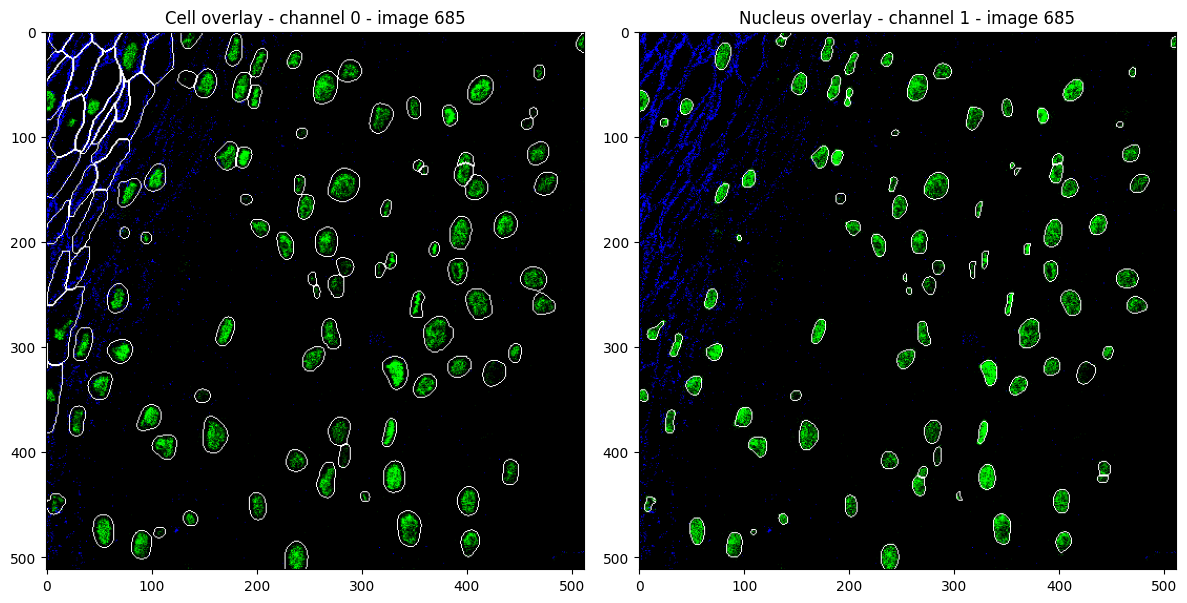

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(overlay_data_cell[0])
axes[0].set_title(f"Cell overlay - channel 0 - image {index}")

axes[1].imshow(overlay_data_nuc[0])
axes[1].set_title(f"Nucleus overlay - channel 1 - image {index}")

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

train_df = pd.DataFrame(train_meta[1:], columns=train_meta[0])

test_df = pd.DataFrame(test_meta[1:], columns=test_meta[0])
test_df = test_df.loc[3:,:].reset_index(drop=True)

val_df = pd.DataFrame(val_meta[1:], columns=val_meta[0])

Delete duplicate rows

In [8]:
train_specimens = set(train_df["specimen"])
val_specimens = set(val_df["specimen"])
test_specimens = set(test_df["specimen"])

print("train = val:", train_specimens == val_specimens)
print("train = test:", train_specimens == test_specimens)
print("val = test:", val_specimens == test_specimens)

train_df['specimen'].value_counts()

train = val: True
train = test: True
val = test: True


specimen
Pancreas                 606
Colon                    452
Breast                   379
Tonsil                   335
Esophagus                333
lymph node metastasis    295
Lymph Node                89
Epidermis                 86
Spleen                     4
Lung                       1
Name: count, dtype: int64

The specimen column in train, val and test dataset clearly shows that Spleen and Lung are severely underrepresented compared with tissues such as Pancreas and Colon.

### Baseline A: use the whole training set for training.

In [9]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.nn.functional import relu

In [10]:
import random
seed = 7

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [11]:
images = torch.randn(1, 2, 256, 256)
model = UNet(n_class=2)
output = model(images)

print(output.shape)

torch.Size([1, 2, 256, 256])


random croping training X and y to 256x256.

transform instance ID in training y to binary number.

In [12]:
train_dataset = TissueNetDataset(train_X, train_y, training=True)
val_dataset = TissueNetDataset(val_X, val_y, training=False)
test_dataset = TissueNetDataset(test_X, test_y, training=False)

batch_size = 2
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [13]:
batch_images, batch_targets = next(iter(train_dataloader))

print('images:', batch_images.shape, batch_images.dtype)
print('targets:', batch_targets.shape, batch_targets.dtype)
print('image range:', batch_images.min().item(), batch_images.max().item())
print('target values:', torch.unique(batch_targets))

model.eval()
with torch.no_grad():
    logits = model(batch_images)

print('model output:', logits.shape)
assert logits.shape == batch_targets.shape

images: torch.Size([2, 2, 256, 256]) torch.float32
targets: torch.Size([2, 2, 256, 256]) torch.float32
image range: 0.0 1.0
target values: tensor([0., 1.])
model output: torch.Size([2, 2, 256, 256])


In [14]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device: {device}")

Device: cuda


In [15]:
model = UNet(n_class=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

In [16]:
checkpoint_path = "best_baseline_a.pt"

best_val_dice = -1.0
best_val_loss = float("inf")
best_epoch = -1

min_delta = 1e-4

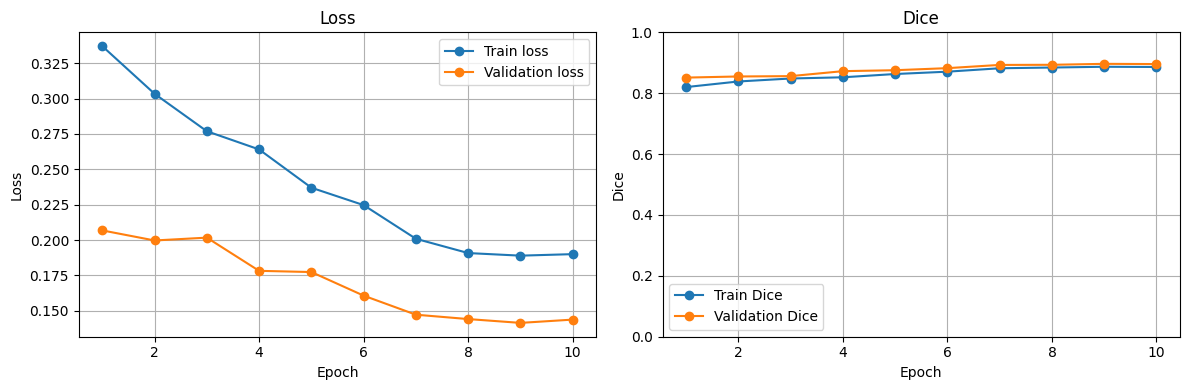

Best epoch: 9
Best validation Dice: 0.8964991048982007
Best validation loss: 0.14152416932761594


In [17]:
epochs = 10

train_losses = []
train_dices = []
val_losses = []
val_dices = []


for epoch in range(epochs):
    train_loss, train_dice = train_one_epoch(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, val_dice = evaluate(val_dataloader, model, loss_fn, device)

    train_losses.append(train_loss)
    train_dices.append(train_dice)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    # Clear the previous epoch display before showing current results.
    clear_output(wait=True)

    # save the model with the best dice and loss
    dice_improved = val_dice > best_val_dice + min_delta

    dice_tied = abs(val_dice - best_val_dice) <= min_delta
    loss_improved = val_loss < best_val_loss

    if dice_improved or (dice_tied and loss_improved):
        best_val_dice = val_dice
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
                "val_dice": best_val_dice,
            },
            checkpoint_path,
        )

        print(
            f"Saved best model at epoch {best_epoch}: "
            f"val Dice={best_val_dice:.4f}, "
            f"val loss={best_val_loss:.4f}"
        )



    epoch_range = range(1, epoch + 2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epoch_range, train_losses, marker="o", label="Train loss")
    axes[0].plot(epoch_range, val_losses, marker="o", label="Validation loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epoch_range, train_dices, marker="o", label="Train Dice")
    axes[1].plot(epoch_range, val_dices, marker="o", label="Validation Dice")
    axes[1].set_title("Dice")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Dice")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    print("Best epoch:", best_epoch)
    print("Best validation Dice:", best_val_dice)
    print("Best validation loss:", best_val_loss)

In [18]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Loaded best epoch:", checkpoint["epoch"])
print("Validation Dice:", checkpoint["val_dice"])
print("Validation loss:", checkpoint["val_loss"])

Loaded best epoch: 9
Validation Dice: 0.8964991048982007
Validation loss: 0.14152416932761594


In [19]:
test_loss, test_dice = evaluate(test_dataloader, model, loss_fn, device)

print(f"Baseline A: \nTest loss: {test_loss:.4f} \nTest Dice: {test_dice:.4f}")

Baseline A: 
Test loss: 0.1802 
Test Dice: 0.8882


Results: 

Baseline A: Training with the whole dataset (10 tissue),   
test loss: 0.1802, test dice: 0.8882. Model saved as best_baseline_a.pt